# Customer Churn Defuser — 02. EDA & Model Training
Exploratory data analysis followed by training and comparing **Logistic Regression**, **Random Forest**, and **Gradient Boosting** classifiers (with GridSearchCV + cross-validation). The best model (by ROC-AUC) is saved as `churn_model.pkl` along with `scaler.pkl`.

> Run `01_Dataset_Generation.ipynb` first, or run `dataset_generator.py`, so `dataset/customer_churn_dataset.csv` exists.

## 1. Imports

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import joblib

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("whitegrid")

## 2. Load Dataset

In [2]:
DATA_PATH = os.path.join("dataset", "customer_churn_dataset.csv")
CHARTS_DIR = os.path.join("static", "images")
MODELS_DIR = "models"
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

FEATURE_COLUMNS = [
    "age", "monthly_fee", "subscription_months", "login_frequency",
    "session_duration", "support_tickets", "payment_failures",
    "last_active_days", "customer_satisfaction", "feature_usage_score",
    "referrals", "engagement_score",
]

df = pd.read_csv(DATA_PATH)
df.head()

,customer_id,age,gender,subscription_type,monthly_fee,subscription_months,login_frequency,session_duration,support_tickets,payment_failures,last_active_days,customer_satisfaction,feature_usage_score,referrals,engagement_score,churn
0,100000,56,Female,Premium,40.11,30,4,18.21,0,1,18,8.7,82.4,2,46.1,1
1,100001,69,Male,Standard,19.87,39,10,14.30,1,1,13,8.2,76.0,1,45.8,0
2,100002,46,Male,Standard,22.88,15,6,8.15,1,0,16,8.3,84.8,1,45.9,0
3,100003,32,Female,Basic,13.12,46,2,4.04,0,0,22,8.4,70.4,1,39.4,0
4,100004,60,Male,Standard,19.71,58,7,20.25,1,1,6,2.7,64.7,0,30.6,1


## 3. Missing Value Analysis & Summary Statistics

In [3]:
df.isnull().sum()

customer_id              0
age                      0
gender                   0
subscription_type        0
monthly_fee              0
subscription_months      0
login_frequency          0
session_duration         0
support_tickets          0
payment_failures         0
last_active_days         0
customer_satisfaction    0
feature_usage_score      0
referrals                0
engagement_score         0
churn                    0
dtype: int64

In [4]:
df[FEATURE_COLUMNS + ['churn']].describe()

,age,monthly_fee,subscription_months,login_frequency,session_duration,support_tickets,payment_failures,last_active_days,customer_satisfaction,feature_usage_score,referrals,engagement_score,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,43.539400,20.128039,30.034500,8.003200,19.829472,1.225200,0.399600,14.209800,6.981090,55.183590,0.601200,36.722550,0.240100
std,14.911636,11.065757,17.126133,2.837674,13.978555,1.110409,0.636051,14.729456,1.723833,19.737553,0.767996,7.136533,0.427165
min,18.000000,5.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.200000,0.000000
25%,31.000000,10.700000,15.000000,6.000000,9.557500,0.000000,0.000000,4.000000,5.800000,41.600000,0.000000,31.900000,0.000000
50%,43.000000,18.790000,30.000000,8.000000,16.700000,1.000000,0.000000,10.000000,7.000000,55.300000,0.000000,36.700000,0.000000
75%,56.000000,22.320000,45.000000,10.000000,26.750000,2.000000,1.000000,20.000000,8.200000,68.600000,1.000000,41.600000,0.000000
max,69.000000,46.700000,59.000000,21.000000,159.900000,8.000000,5.000000,143.000000,10.000000,100.000000,6.000000,58.700000,1.000000


## 4. Churn Distribution

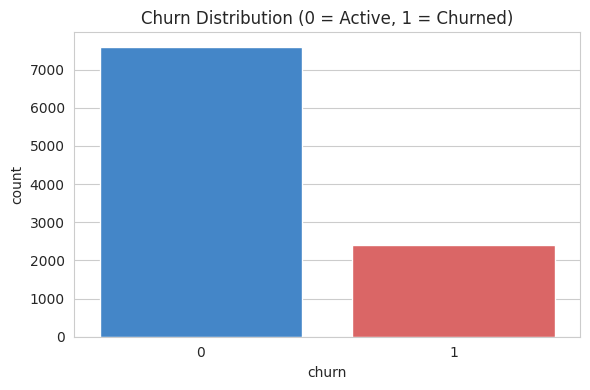

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="churn", data=df, palette=["#2E86DE", "#EE5253"])
plt.title("Churn Distribution (0 = Active, 1 = Churned)")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "churn_distribution.png"))
plt.show()

## 5. Correlation Heatmap

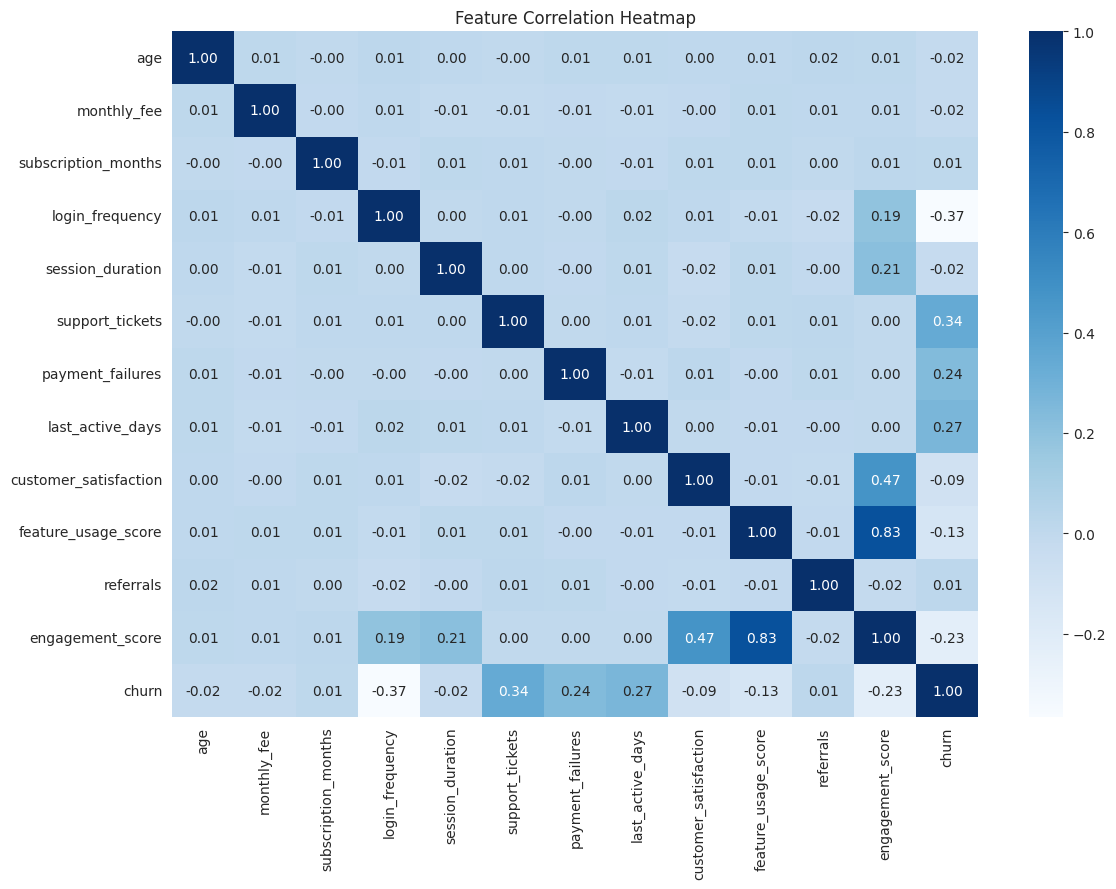

In [6]:
plt.figure(figsize=(12, 9))
corr = df[FEATURE_COLUMNS + ["churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "correlation_heatmap.png"))
plt.show()

## 6. Feature Distributions

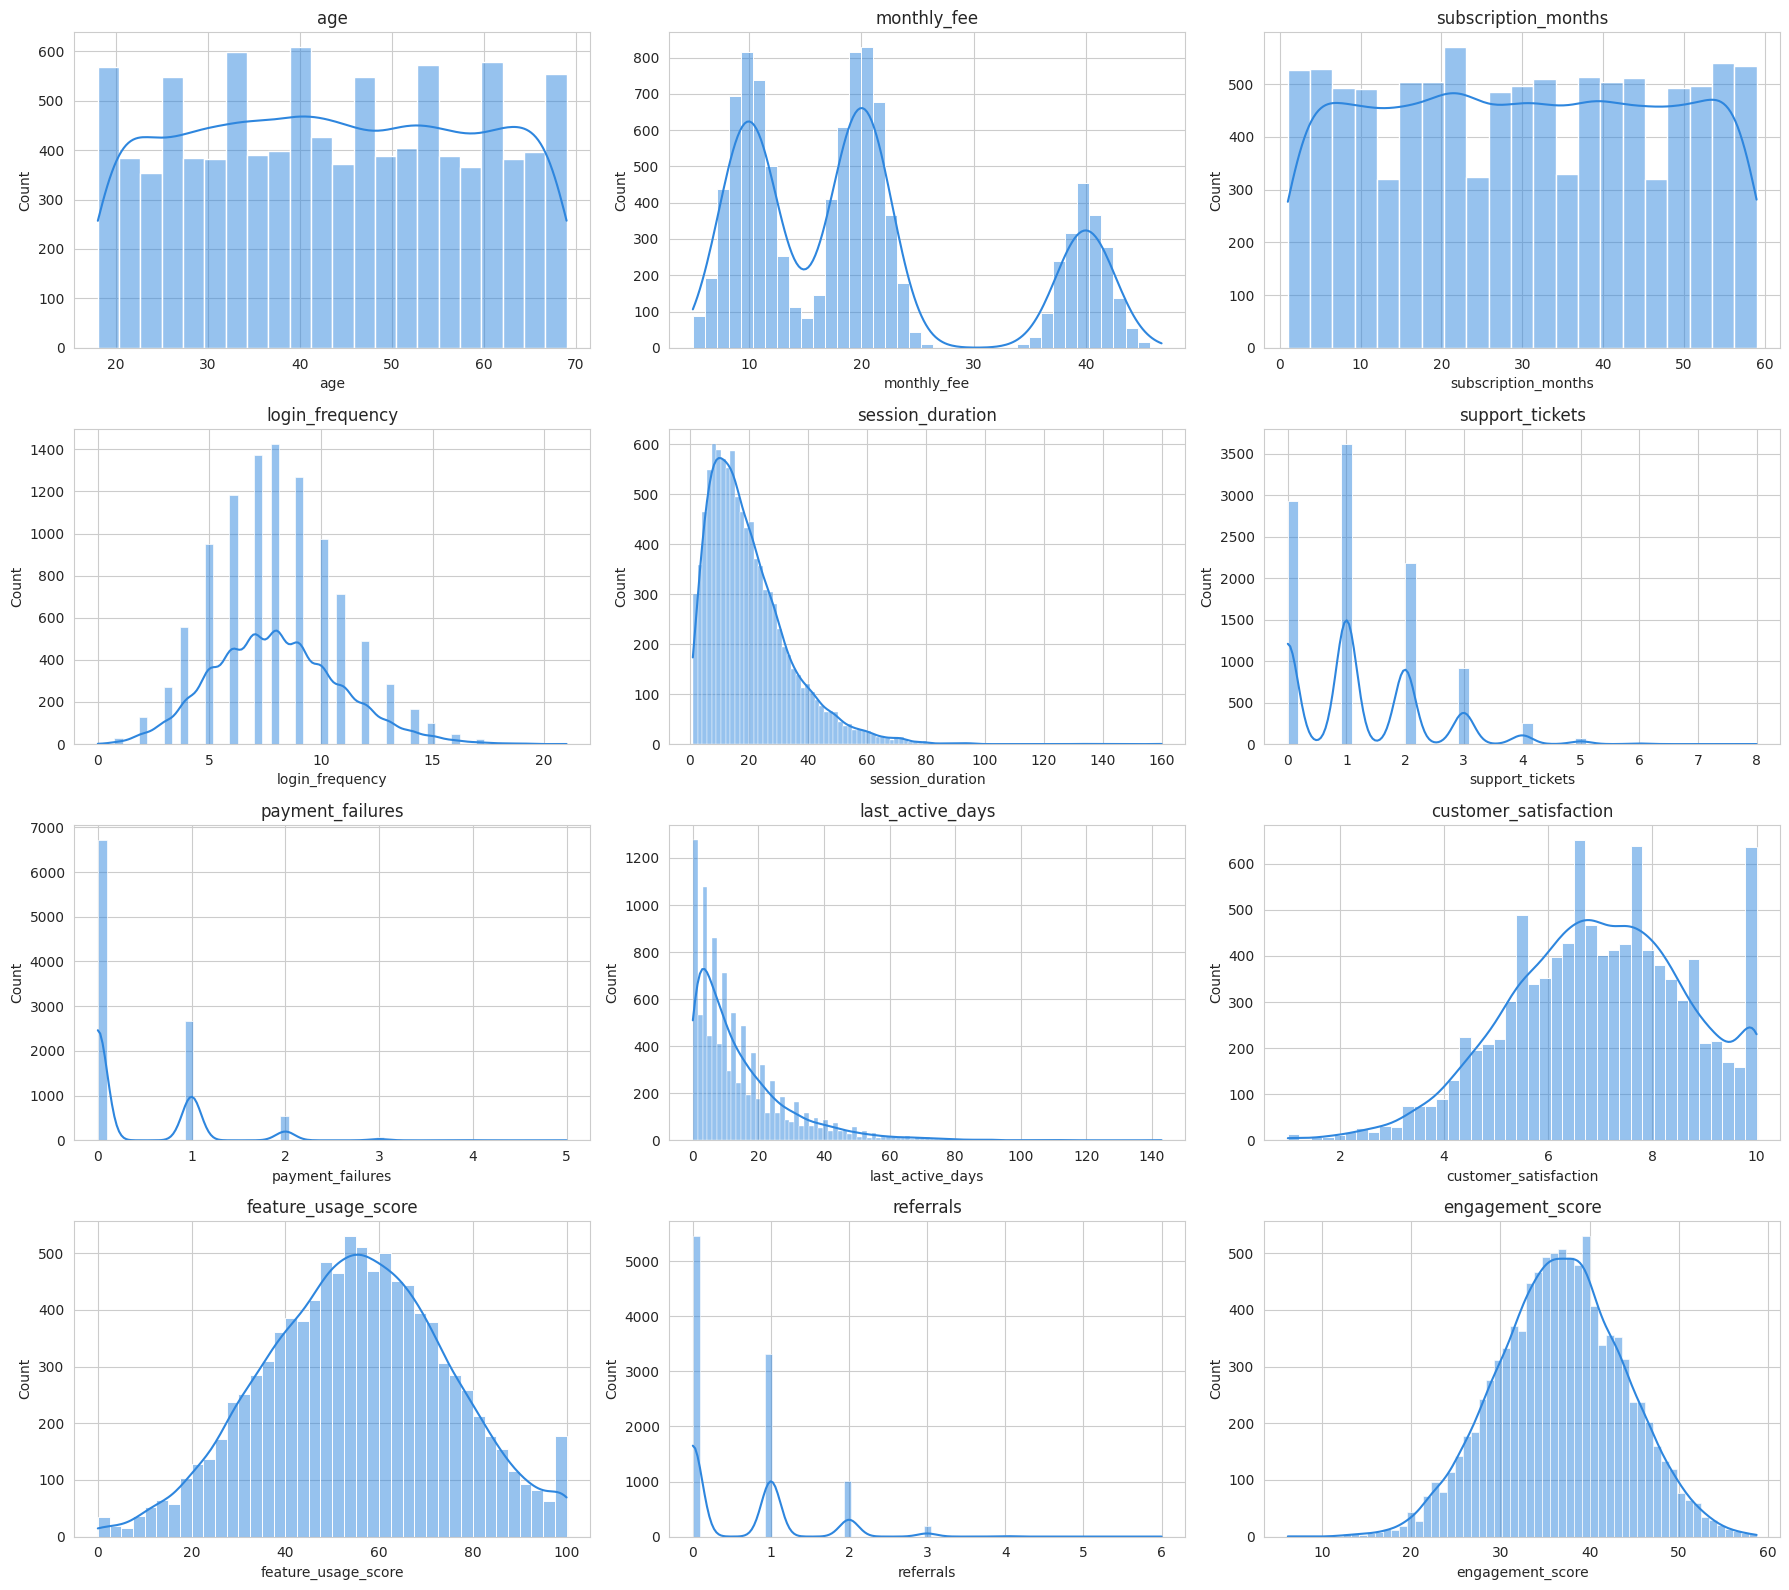

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.histplot(df[col], kde=True, ax=ax, color="#2E86DE")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "feature_distributions.png"))
plt.show()

## 7. Pair Plot (Sample)

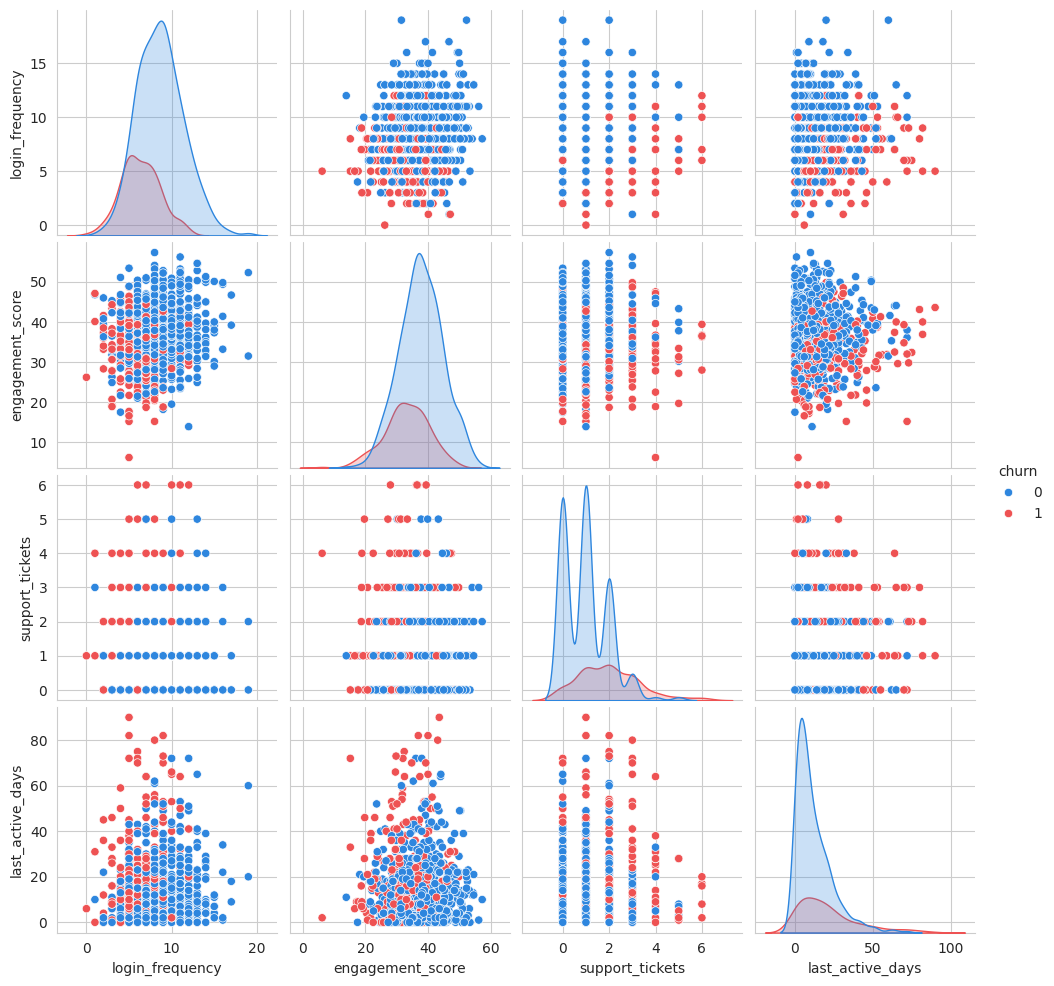

In [8]:
sample_df = df.sample(min(1000, len(df)), random_state=42)
pair_cols = ["login_frequency", "engagement_score", "support_tickets", "last_active_days", "churn"]
pp = sns.pairplot(sample_df[pair_cols], hue="churn", palette=["#2E86DE", "#EE5253"])
pp.savefig(os.path.join(CHARTS_DIR, "pairplot.png"))
plt.show()

## 8. Train / Test Split & Scaling

In [9]:
X = df[FEATURE_COLUMNS].copy()
y = df["churn"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(8000, 12) (2000, 12)


## 9. Define Models & Hyperparameter Grids
Logistic Regression, Random Forest, and Gradient Boosting, each tuned via `GridSearchCV` with 5-fold stratified cross-validation, scoring on ROC-AUC.

In [10]:
model_specs = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {"C": [0.01, 0.1, 1, 10]},
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "max_depth": [6, 10, None]},
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
        },
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 10. Train, Tune, and Compare Models

In [11]:
results = {}
fitted_models = {}

for name, spec in model_specs.items():
    print(f"Training {name} with GridSearchCV...")
    grid = GridSearchCV(spec["model"], spec["params"], cv=cv, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "best_params": grid.best_params_,
    }

    results[name] = metrics
    fitted_models[name] = best_model
    print(f"{name} -> {metrics}\n")

Training LogisticRegression with GridSearchCV...
LogisticRegression -> {'accuracy': 0.8805, 'precision': 0.7822014051522248, 'recall': 0.6958333333333333, 'f1_score': 0.7364939360529217, 'roc_auc': 0.9340405701754386, 'best_params': {'C': 0.1}}

Training RandomForest with GridSearchCV...


RandomForest -> {'accuracy': 0.87, 'precision': 0.8072625698324022, 'recall': 0.6020833333333333, 'f1_score': 0.6897374701670644, 'roc_auc': 0.9183580043859649, 'best_params': {'max_depth': 10, 'n_estimators': 200}}

Training GradientBoosting with GridSearchCV...


GradientBoosting -> {'accuracy': 0.8745, 'precision': 0.7706855791962175, 'recall': 0.6791666666666667, 'f1_score': 0.7220376522702104, 'roc_auc': 0.9246121162280702, 'best_params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}}



## 11. Compare Results

In [12]:
results_df = pd.DataFrame(results).T
results_df[["accuracy", "precision", "recall", "f1_score", "roc_auc"]]

,accuracy,precision,recall,f1_score,roc_auc
LogisticRegression,0.8805,0.782201,0.695833,0.736494,0.934041
RandomForest,0.87,0.807263,0.602083,0.689737,0.918358
GradientBoosting,0.8745,0.770686,0.679167,0.722038,0.924612


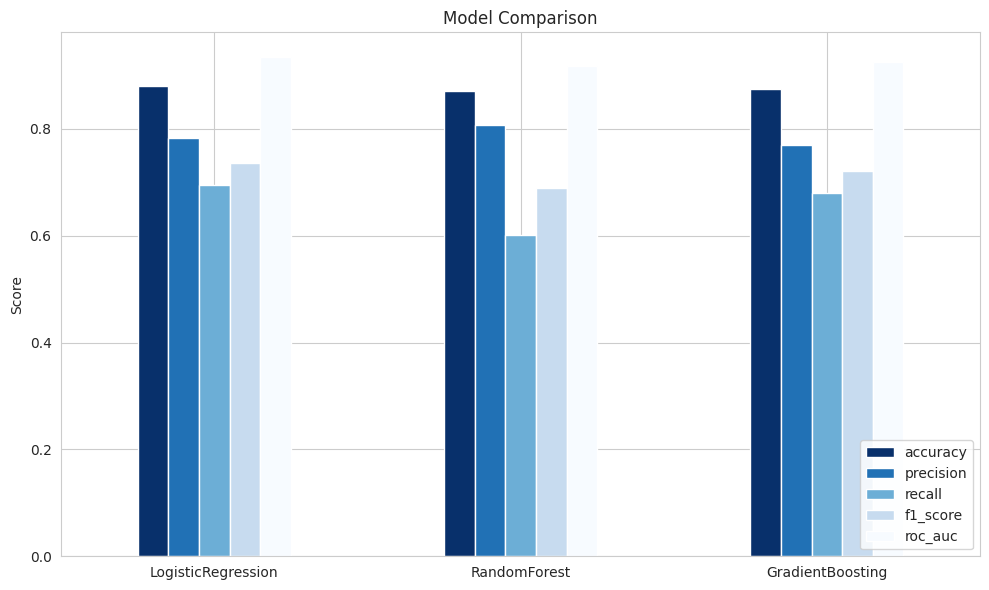

In [13]:
results_df[["accuracy", "precision", "recall", "f1_score", "roc_auc"]].astype(float).plot(
    kind="bar", figsize=(10, 6), colormap="Blues_r"
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 12. Select Best Model (by ROC-AUC)

In [14]:
best_name = max(results, key=lambda k: results[k]["roc_auc"])
best_model = fitted_models[best_name]

print(f"Best model: {best_name}")
print(results[best_name])

Best model: LogisticRegression
{'accuracy': 0.8805, 'precision': 0.7822014051522248, 'recall': 0.6958333333333333, 'f1_score': 0.7364939360529217, 'roc_auc': 0.9340405701754386, 'best_params': {'C': 0.1}}


## 13. Confusion Matrix for the Best Model

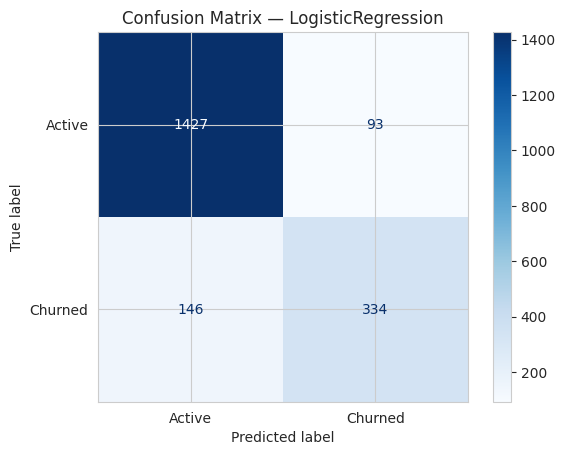

In [15]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Active", "Churned"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

## 14. Feature Importance

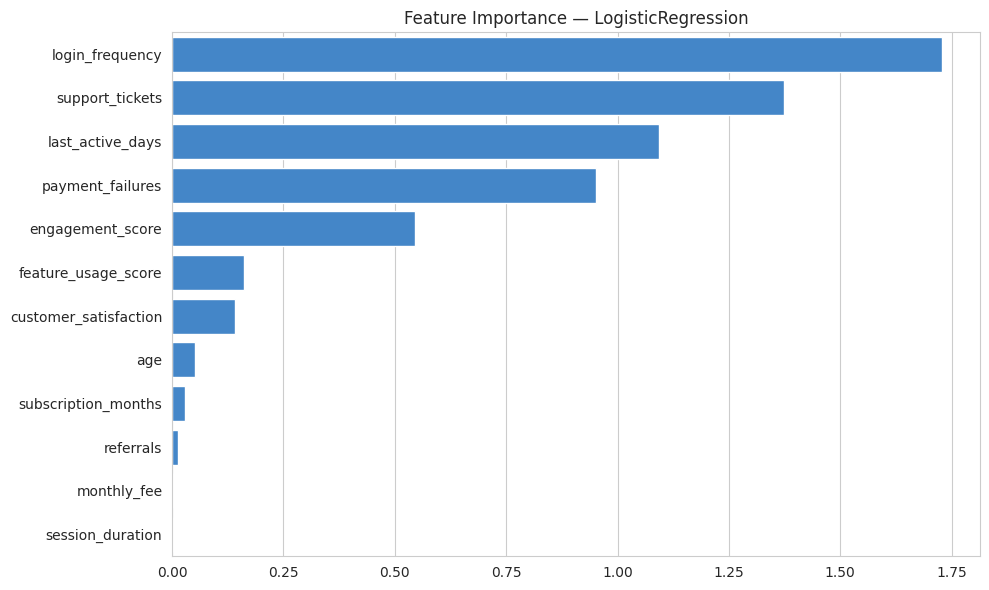

In [16]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.zeros(len(FEATURE_COLUMNS))

idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[idx], y=np.array(FEATURE_COLUMNS)[idx], color="#2E86DE")
plt.title(f"Feature Importance — {best_name}")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "feature_importance.png"))
plt.show()

## 15. Save Model, Scaler & Metrics

In [17]:
joblib.dump(best_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

with open(os.path.join(MODELS_DIR, "model_metrics.json"), "w") as f:
    json.dump(
        {"best_model": best_name, "all_results": results, "feature_columns": FEATURE_COLUMNS},
        f, indent=2, default=str,
    )

print("Saved churn_model.pkl, scaler.pkl, and models/model_metrics.json")

Saved churn_model.pkl, scaler.pkl, and models/model_metrics.json


## 16. Quick Sanity Check
Try the saved model on a single hand-crafted example.

In [18]:
sample_customer = pd.DataFrame([{
    "age": 30, "monthly_fee": 19.99, "subscription_months": 12,
    "login_frequency": 2, "session_duration": 5, "support_tickets": 5,
    "payment_failures": 3, "last_active_days": 80, "customer_satisfaction": 3,
    "feature_usage_score": 20, "referrals": 0, "engagement_score": 15,
}])[FEATURE_COLUMNS]

scaled_sample = scaler.transform(sample_customer)
risk = best_model.predict_proba(scaled_sample)[0][1] * 100
print(f"Predicted churn risk: {risk:.2f}%")

Predicted churn risk: 100.00%
